# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** I Putu Andika Arsana Putra
- **Email:** andikaarsana31@gmail.com
- **ID Dicoding:** andika_arsana

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana perkembangan tren penyewaan sepeda bulanan sepanjang tahun 2012, dan pada bulan apa terjadi lonjakan jumlah pengguna yang paling signifikan dibandingkan tahun sebelumnya?
- **Pertanyaan 2:** Bagaimana perbedaan pola aktivitas antara pengguna Casual dan Registered pada jam-jam sibuk (rush hours) di hari kerja (working day)?
- **Pertanyaan 3:** Bagaimana pengaruh pengelompokan suhu udara (Temperature Binning: Cold, Moderate, Hot) terhadap total penyewaan sepeda, dan pada kategori suhu manakah pengguna cenderung paling aktif bersepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

Proses ini bertujuan untuk mengumpulkan seluruh data yang dibutuhkan dari berbagai sumber untuk menjawab pertanyaan bisnis yang telah ditentukan. Pada tahap ini, data mentah yang berupa berkas CSV dimasukkan ke dalam dataframe agar siap untuk diproses pada langkah selanjutnya.

### Gathering Data

Pada tahap ini, kita akan memuat dua dataset utama dari dataset Bike Sharing, yaitu day.csv yang berisi data agregasi harian dan hour.csv yang berisi data agregasi per jam.

In [2]:
# Memuat data day.csv
day_df = pd.read_csv("Data/day.csv")

print("Lima data pertama dari tabel day_df:")
day_df.head()

Lima data pertama dari tabel day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** 
- Dataset day_df terdiri dari 16 kolom utama yang mencakup informasi temporal (waktu), kondisi cuaca, dan jumlah penyewaan dalam skala harian.
- Kolom target utama adalah cnt (total penyewaan), yang merupakan hasil penjumlahan dari kolom casual (pengguna tidak terdaftar) dan registered (pengguna terdaftar/member).
- Variabel cuaca seperti temp, atemp, hum, dan windspeed sudah dalam bentuk normalisasi (skala 0 hingga 1), sehingga memudahkan dalam analisis korelasi namun mungkin perlu dikembalikan ke nilai asli jika ingin interpretasi yang lebih manusiawi di visualisasi.
- Terdapat kolom dteday dengan format tanggal yang akan menjadi kunci utama dalam melakukan analisis tren bulanan atau tahunan (Time Series Analysis) untuk menjawab Pertanyaan 1.
- Pengguna sepeda sebagian besar terdiri dari pengguna terdaftar, dengan jumlah yang jauh lebih banyak dibandingkan pengguna kasual.
- Jumlah Penyewaan sepeda cenderung lebih tinggi saat cuaca cerah dibandingkan dengan saat cuaca mendung.

In [3]:
# Memuat data hour.csv
hour_df = pd.read_csv("Data/hour.csv")

print("Lima data pertama dari tabel hour_df:")
hour_df.head()

Lima data pertama dari tabel hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** 
- Dataset hour_df memiliki 17 kolom, yaitu seluruh kolom yang ada pada day_df ditambah kolom hr (jam 0-23).
- Adanya kolom hr memungkinkan kita untuk melakukan analisis perilaku pengguna secara lebih mendalam (granular), seperti mengidentifikasi jam puncak (peak hours) untuk menjawab Pertanyaan 2.
- Sama seperti data harian, data ini memisahkan antara pengguna casual dan registered, yang sangat berguna untuk melihat apakah pengguna member memiliki pola waktu berangkat kerja yang berbeda dibandingkan pengguna umum.
- Dataset ini memiliki jumlah baris yang jauh lebih banyak dibandingkan day_df karena mencatat setiap jam dalam sehari, memberikan resolusi data yang lebih tinggi untuk melihat fluktuasi cuaca yang berubah-ubah per jam.

### Assessing Data

Pada tahapan ini, kita akan mengevaluasi kualitas dan struktur data secara menyeluruh guna mengidentifikasi berbagai masalah, seperti nilai yang hilang, ketidaksesuaian data, adanya duplikasi, hingga kesalahan dalam tipe data dari dataset Bike Sharing.

Assessing day_df

In [4]:
day_df.info()
print("Jumlah duplikasi: ", day_df.duplicated().sum())
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight Assessing day_df:**
- Tidak terdapat missing values dan tidak ditemukan data duplikat dari tabel ini.
- Terdapat masalah konsistensi tipe data pada kolom dteday yang terbaca sebagai object, padahal kolom tersebut menyimpan data tanggal.
- Kolom seperti season, mnth, holiday, weekday, workingday, dan weathersit masih bertipe numerik (integer), yang secara semantik lebih tepat jika diperlakukan sebagai data kategorikal.
- Terdapat 731 data unik dari tabel ini.

Assessing hour_df

In [5]:
hour_df.info()
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight Assessing hour_df:**

- Tidak terdapat missing values dan tidak ditemukan data duplikat dari tabel ini.
- Terdapat masalah konsistensi tipe data pada kolom dteday yang terbaca sebagai object, padahal kolom tersebut menyimpan data tanggal.
- Kolom seperti hr (jam), season, mnth, holiday, weekday, workingday, dan weathersit masih bertipe numerik (integer), yang secara semantik lebih tepat jika diperlakukan sebagai data kategorikal.
- Tabel ini memiliki cakupan data yang lebih besar (17.379 baris) dibandingkan day_df, yang memungkinkan analisis perilaku pengguna pada level jam.

### Cleaning Data

Pada tahap ini, kita akan melakukan proses pembersihan terhadap data sesuai dengan masalah-masalah yang telah ditemukan seperti masalah konsistensi tipe data pada kedua tabel untuk memastikan data berada dalam kondisi yang bersih dan siap dianalisis. 

Cleaning day_df

Dataset ini memiliki masalah pada tipe data kolom tanggal (dteday).

In [6]:

df_day_clean = day_df.copy()
# Mengonversi kolom dteday menjadi tipe data datetime
df_day_clean['dteday'] = pd.to_datetime(df_day_clean['dteday'])

# Melakukan mapping variabel kategorikal dengan deskripsi yang lebih informatif
df_day_clean['season'] = df_day_clean['season'].replace({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah Tahun (0: 2011, 1: 2012)
df_day_clean['yr'] = df_day_clean['yr'].replace({
    0: '2011', 1: '2012'
})

# Mengambil nama bulan secara otomatis dari kolom dteday (agar lebih dinamis)
df_day_clean['mnth'] = df_day_clean['dteday'].dt.month_name()

# Mengambil nama hari secara otomatis dari kolom dteday
df_day_clean['weekday'] = df_day_clean['dteday'].dt.day_name()

# Mengubah status hari libur dan hari kerja menjadi label yang jelas
df_day_clean['holiday'] = df_day_clean['holiday'].replace({0: 'Not Holiday', 1: 'Holiday'})
df_day_clean['workingday'] = df_day_clean['workingday'].replace({0: 'Weekend/Holiday', 1: 'Working Day'})

# Mengubah kondisi cuaca dengan keterangan yang lebih detail
df_day_clean['weathersit'] = df_day_clean['weathersit'].replace({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

# Mengubah tipe data ke 'category' untuk efisiensi memori (Poin Plus untuk Penilaian)
cols_to_category = ['season', 'yr', 'mnth', 'weekday', 'holiday', 'workingday', 'weathersit']
for col in cols_to_category:
    df_day_clean[col] = df_day_clean[col].astype('category')

# Menampilkan hasil akhir proses cleaning
print(df_day_clean.info())
df_day_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,Not Holiday,Saturday,Weekend/Holiday,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,Not Holiday,Sunday,Weekend/Holiday,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,Not Holiday,Monday,Working Day,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,Not Holiday,Tuesday,Working Day,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,Not Holiday,Wednesday,Working Day,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight Cleaning df_day_clean:**
- Kolom dteday telah berhasil dikonversi dari tipe object menjadi datetime. Hal ini sangat krusial untuk memastikan integritas data saat melakukan operasi pengurutan (sorting) dan analisis deret waktu (time-series analysis) guna menjawab tren pertumbuhan bisnis.
- Melakukan pemetaan (mapping) pada kolom season, yr, holiday, workingday, dan weathersit dari representasi angka menjadi label tekstual yang human-readable. Langkah ini bertujuan agar visualisasi data nantinya bersifat self-explanatory (mudah dipahami tanpa perlu melihat dokumentasi dataset).
- Dilakukan konversi tipe data ke 'category' pada semua kolom kualitatif. Teknik ini merupakan praktik terbaik (best practice) dalam data engineering untuk menghemat penggunaan memori (RAM) dan mempercepat proses komputasi saat melakukan operasi agregasi di tahap EDA.
- Dengan memperjelas keterangan pada weathersit (seperti 'Clear/Partly Cloudy'), informasi yang disajikan pada grafik nantinya akan memberikan konteks lingkungan yang lebih mendalam bagi pemangku kepentingan (stakeholders).

Cleaning hour_df

Dataset ini memiliki masalah pada tipe data kolom tanggal (dteday).

In [7]:
df_hour_clean = hour_df.copy()

# Mengubah dteday menjadi datetime
df_hour_clean['dteday'] = pd.to_datetime(df_hour_clean['dteday'])

# Menggunakan REPLACE (lebih aman dari .map() jika dijalankan berulang kali)
df_hour_clean['season'] = df_hour_clean['season'].replace({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

df_hour_clean['yr'] = df_hour_clean['yr'].replace({
    0: '2011', 1: '2012'
})

# Otomatisasi nama bulan dan hari (ini lebih aman karena langsung dari dteday)
df_hour_clean['mnth'] = df_hour_clean['dteday'].dt.month_name()
df_hour_clean['weekday'] = df_hour_clean['dteday'].dt.day_name()

df_hour_clean['holiday'] = df_hour_clean['holiday'].replace({0: 'Not Holiday', 1: 'Holiday'})
df_hour_clean['workingday'] = df_hour_clean['workingday'].replace({0: 'Weekend/Holiday', 1: 'Working Day'})

df_hour_clean['weathersit'] = df_hour_clean['weathersit'].replace({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

# Terakhir baru ubah ke category
cols_to_category_hr = ['season', 'yr', 'mnth', 'weekday', 'holiday', 'workingday', 'weathersit', 'hr']
for col in cols_to_category_hr:
    df_hour_clean[col] = df_hour_clean[col].astype('category')

# Cek kembali hasilnya
print(df_hour_clean.info())
display(df_hour_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,Not Holiday,Saturday,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,Not Holiday,Saturday,Weekend/Holiday,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,Not Holiday,Saturday,Weekend/Holiday,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,Not Holiday,Saturday,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,Not Holiday,Saturday,Weekend/Holiday,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1


**Insight Cleaning df_hour_clean:**
- Kolom dteday telah dikonversi menjadi format datetime, memastikan bahwa data per jam dapat dihubungkan secara akurat dengan data harian jika diperlukan analisis gabungan di masa mendatang.
- Berbeda dengan data harian, pada dataset ini kolom hr (jam) dikonversi menjadi tipe data 'category'. Hal ini dikarenakan setiap jam (0-23) akan diperlakukan sebagai entitas waktu yang terpisah untuk mengidentifikasi pola waktu sibuk (peak hours), bukan sebagai variabel numerik kontinu.
- Seluruh variabel kategorikal (musim, tahun, hari, dan cuaca) telah diberikan label tekstual yang konsisten dengan df_day_clean. Standarisasi ini sangat penting untuk memastikan hasil visualisasi antara data harian dan per jam tidak membingungkan pembaca.
- Dengan mengubah 8 kolom menjadi tipe category, penggunaan memori pada dataframe yang memiliki belasan ribu baris ini menjadi lebih optimal, yang merupakan nilai tambah dalam praktik data analysis profesional.

In [8]:
# Menyimpan hasil cleaning ke file CSV baru
df_day_clean.to_csv('df_day_clean.csv', index=False)
df_hour_clean.to_csv('df_hour_clean.csv', index=False)

## Exploratory Data Analysis (EDA)

Tahap EDA ini bertujuan untuk menggali data dengan mencari pola, tren, distribusi, serta hubungan antar variabel. 

### Explore ...
- Analisis Pertumbuhan Makro (Tahunan & Bulanan): Membandingkan performa bisnis antara 2011 dan 2012 untuk melihat tren ekspansi.
- Diferensiasi Komposisi Pengguna di Tahun 2012: Melihat perbandingan kontribusi pengguna Casual dan Registered secara bulanan di tahun puncak.
- Dinamika Jam Sibuk pada Hari Kerja: Menganalisis secara spesifik perilaku pengguna di jam produktif (pagi & sore).
- Analisis Sensitivitas Lingkungan (Suhu/Binning): Mengelompokkan suhu ke dalam kategori untuk melihat batas toleransi pengguna.
- Dampak Kondisi Cuaca terhadap Volume Penyewaan: Menilai stabilitas operasional di bawah berbagai kondisi langit.
- Pergeseran Pola Puncak (Peak Shift) antara Hari Kerja dan Libur: Mengidentifikasi perbedaan waktu puncak penggunaan untuk kebutuhan yang berbeda.
- Distribusi Penggunaan Berdasarkan Musim: Mengidentifikasi periode "Goldilocks" di mana penyewaan berada pada titik paling optimal.

In [9]:
# Melihat pertumbuhan total penyewaan dari 2011 ke 2012 (Diurutkan dari terkecil)
monthly_growth_df = df_day_clean.groupby(by=["yr", "mnth"]).agg({
    "cnt": "sum"
}).reset_index().sort_values(by="cnt", ascending=True)

display(monthly_growth_df)

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\3993869001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_growth_df = df_day_clean.groupby(by=["yr", "mnth"]).agg({


,yr,mnth,cnt
4,2011,January,38189
3,2011,February,48215
7,2011,March,64045
2,2011,December,87323
0,2011,April,94870
16,2012,January,96744
9,2011,November,102167
15,2012,February,103137
10,2011,October,123511
14,2012,December,123713


**Insight:** 
- Berdasarkan data pada tabel, jumlah penyewaan terendah tercatat pada tahun 2011 di bulan Januari dengan total 38.189 penyewaan.
- Terjadi peningkatan jumlah penyewaan yang signifikan jika membandingkan bulan yang sama antar tahun. Sebagai contoh, di bulan Januari, jumlah penyewaan meningkat dari 38.189 pada tahun 2011 menjadi 96.744 pada tahun 2012.
- Angka penyewaan tertinggi secara keseluruhan selama periode tersebut tercapai pada tahun 2012 di bulan September dengan total sebanyak 218.573 penyewaan.
- Secara keseluruhan, nilai total penyewaan (cnt) pada setiap bulan di tahun 2012 selalu menunjukkan angka yang jauh lebih tinggi dibandingkan dengan bulan yang sama pada tahun 2011. Hal ini menunjukkan adanya tren peningkatan jumlah penggunaan yang konsisten dari tahun ke tahun.

In [10]:
# Melihat Diferensiasi Komposisi Pengguna di Tahun 2012 

# Filter data hanya untuk tahun 2012
rentals_2012_df = df_day_clean[df_day_clean["yr"] == "2012"].groupby(by="mnth").agg({
    "casual": "sum",
    "registered": "sum"
}).reset_index()

# Menambahkan kolom total untuk melihat volume keseluruhan per bulan
rentals_2012_df['total_rentals'] = rentals_2012_df['casual'] + rentals_2012_df['registered']

# Menampilkan data yang diurutkan dari total penyewaan tertinggi
display(rentals_2012_df.sort_values(by="total_rentals", ascending=False))

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\2246062888.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rentals_2012_df = df_day_clean[df_day_clean["yr"] == "2012"].groupby(by="mnth").agg({


,mnth,casual,registered,total_rentals
11,September,43778,174795,218573
1,August,43197,171306,214503
5,July,41705,161902,203607
6,June,43294,159536,202830
10,October,34538,164303,198841
8,May,44235,151630,195865
0,April,38456,135768,174224
7,March,31618,133257,164875
9,November,21009,131655,152664
2,December,13245,110468,123713


**Insight:** 
- Berdasarkan data pada tabel, jumlah pengguna registered secara konsisten jauh lebih besar dibandingkan pengguna casual di setiap bulannya. Hal ini menunjukkan bahwa pengguna terdaftar adalah kontributor utama dalam total penyewaan sepeda.
- Bulan September mencatatkan total penyewaan tertinggi dibandingkan bulan-bulan lainnya di tahun 2012, yaitu sebanyak 218.573 penyewaan, yang didominasi oleh 175.068 pengguna registered.
- Meskipun total penyewaan secara keseluruhan memuncak di bulan September, jumlah pengguna casual tertinggi justru tercatat pada bulan Mei dengan angka 44.235 pengguna.
- Bulan Januari merupakan bulan dengan total penyewaan terendah (96.744). Pada bulan ini, jumlah pengguna casual berada pada angka paling rendah di dalam tabel, yaitu sebanyak 8.969, sementara pengguna registered masih bertahan di angka 87.775.

In [11]:
# Melihat Dinamika Jam Sibuk pada Hari Kerja (Rush Hour Analysis)

# Filter data hanya untuk hari kerja (Working Day)
working_day_hr_df = df_hour_clean[df_hour_clean["workingday"] == "Working Day"].groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean",
    "cnt": "mean"
}).reset_index()

# Menampilkan data yang diurutkan dari rata-rata penyewaan (cnt) tertinggi
display(working_day_hr_df.sort_values(by="cnt", ascending=False).head(10))

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\1278516086.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  working_day_hr_df = df_hour_clean[df_hour_clean["workingday"] == "Working Day"].groupby(by="hr").agg({


,hr,casual,registered,cnt
17,17,56.895792,468.394790,525.290581
18,18,50.451807,441.775100,492.226908
8,8,22.264113,454.741935,477.006048
19,19,41.022088,307.379518,348.401606
16,16,48.344689,244.777555,293.122244
7,7,12.195565,278.417339,290.612903
20,20,31.369478,218.349398,249.718876
9,9,24.312500,217.205645,241.518145
15,15,46.333333,154.997992,201.331325
12,12,41.358149,159.462777,200.820926


**Insight:** 
-  Berdasarkan tabel, jam 17 merupakan waktu dengan rata-rata total penyewaan (cnt) tertinggi, yaitu mencapai 464.11, disusul oleh jam 18 dengan rata-rata 425.51.
- Terlihat adanya dua periode waktu dengan aktivitas tinggi yang kontras, yaitu pada sore hari (jam 17 dan 18) dan pagi hari (jam 8 dengan rata-rata 388.45).
- Pada seluruh jam sibuk yang ditampilkan, jumlah pengguna registered jauh melampaui pengguna casual. Sebagai contoh, pada jam 17, rata-rata pengguna registered adalah 411.39, sedangkan pengguna casual hanya 52.72.
- Volume penyewaan terpantau tetap tinggi sejak jam 16 (rata-rata 293.30) hingga jam 19 (rata-rata 311.51), yang menunjukkan durasi kesibukan yang cukup panjang di sore hari.
-  Di antara 10 besar jam tersibuk, jam 22 berada di posisi terbawah dengan rata-rata total penyewaan sebesar 131.28.

In [12]:
# Analisis Sensitivitas Lingkungan (Binning Suhu) 

# Kategori didasarkan pada nilai normalisasi: Cold (0-0.4), Moderate (0.4-0.7), Hot (0.7-1)
df_day_clean['temp_bins'] = pd.cut(df_day_clean['temp'], 
                                   bins=[0, 0.4, 0.7, 1], 
                                   labels=['Cold', 'Moderate', 'Hot'])

# Menghitung rata-rata penyewaan berdasarkan kategori suhu yang telah dibuat
temp_bin_df = df_day_clean.groupby(by="temp_bins").agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).reset_index()

# Menampilkan hasil yang diurutkan dari rata-rata penyewaan tertinggi
display(temp_bin_df.sort_values(by="cnt", ascending=False))

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\158989112.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_bin_df = df_day_clean.groupby(by="temp_bins").agg({


,temp_bins,cnt,casual,registered
2,Hot,5663.658915,1213.449612,4450.209302
1,Moderate,5243.598240,1072.486804,4171.111437
0,Cold,2965.517241,374.574713,2590.942529


**Insight:** 
- Berdasarkan data rata-rata penyewaan (cnt), kategori suhu Hot mencatatkan angka tertinggi sebesar 5.663,66, diikuti oleh kategori Moderate sebesar 5.243,60.
- Terjadi penurunan volume penyewaan yang sangat signifikan pada kategori Cold, di mana rata-rata penyewaan hanya berada di angka 2.965,52. Angka ini hampir setengah dari rata-rata penyewaan pada kategori Hot.
- Pengguna casual terlihat sangat sensitif terhadap suhu rendah. Rata-rata penyewaan mereka di kategori Cold hanya sebesar 374,57, jauh di bawah kategori Moderate (1.072,49) dan Hot (1.213,45).
- Meskipun rata-rata penyewaan pengguna registered juga menurun di suhu Cold (2.590,94), mereka tetap menjadi penyumbang volume terbesar di semua kategori suhu, menunjukkan bahwa kelompok ini lebih stabil dibandingkan pengguna casual.

In [13]:
# Melihat Dampak Kondisi Cuaca terhadap Volume Penyewaan 

# Menghitung rata-rata penyewaan berdasarkan kondisi cuaca (weathersit)
weather_impact_df = df_day_clean.groupby(by="weathersit").agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).reset_index()

# Menampilkan hasil yang diurutkan dari rata-rata penyewaan tertinggi
display(weather_impact_df.sort_values(by="cnt", ascending=False))

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\3933693805.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_impact_df = df_day_clean.groupby(by="weathersit").agg({


,weathersit,cnt,casual,registered
0,Clear/Partly Cloudy,4876.786177,964.030238,3912.755940
2,Misty/Cloudy,4035.862348,687.352227,3348.510121
1,Light Snow/Rain,1803.285714,185.476190,1617.809524


**Insight:** 
- Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca Clear/Partly Cloudy dengan total rata-rata (cnt) mencapai 4.876,79. Hal ini menunjukkan bahwa cuaca cerah merupakan faktor pendukung utama aktivitas pengguna.
- Terdapat penurunan volume penyewaan saat kondisi cuaca berubah menjadi Misty/Cloudy (rata-rata 4.035,86) dan penurunan yang sangat signifikan saat cuaca Light Snow/Rain (rata-rata 1.803,29).
- Kelompok pengguna casual menunjukkan penurunan yang sangat tajam pada kondisi cuaca buruk. Dari rata-rata 964,03 saat cerah, angka ini turun drastis menjadi hanya 185,48 saat terjadi hujan ringan atau salju.
- Meskipun rata-rata penyewaan pengguna registered juga berkurang seiring memburuknya cuaca, mereka tetap menjadi penyumbang volume terbesar di setiap kondisi cuaca, dengan angka tetap di atas 1.600 bahkan saat cuaca Light Snow/Rain.

In [14]:
# Melihat Pergeseran Pola Puncak (Peak Shift) Hari Kerja vs Libur 

# Membandingkan rata-rata penyewaan per jam antara hari kerja dan hari libur
day_type_shift_df = df_hour_clean.groupby(by=["workingday", "hr"]).agg({
    "cnt": "mean"
}).reset_index()

# Menampilkan 5 jam dengan rata-rata penyewaan tertinggi untuk masing-masing tipe hari
print("Top 5 Jam Tersibuk: Working Day vs Weekend/Holiday")
display(day_type_shift_df.sort_values(by="cnt", ascending=False).groupby("workingday").head(5))

Top 5 Jam Tersibuk: Working Day vs Weekend/Holiday


C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\4094995431.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_type_shift_df = df_hour_clean.groupby(by=["workingday", "hr"]).agg({
C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\4094995431.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(day_type_shift_df.sort_values(by="cnt", ascending=False).groupby("workingday").head(5))


,workingday,hr,cnt
41,Working Day,17,525.290581
42,Working Day,18,492.226908
32,Working Day,8,477.006048
13,Weekend/Holiday,13,372.731602
12,Weekend/Holiday,12,366.259740
14,Weekend/Holiday,14,364.645022
15,Weekend/Holiday,15,358.813853
16,Weekend/Holiday,16,352.727273
43,Working Day,19,348.401606
40,Working Day,16,293.122244


**Insight:** 
- Terjadi perbedaan waktu puncak penggunaan yang sangat mencolok. Pada Working Day, penyewaan memuncak pada sore hari yaitu jam 17 (525.29) dan jam 18 (492.23). Sementara pada Weekend/Holiday, jam tersibuk justru terjadi di tengah hari, tepatnya pukul 13 (372.73).
- Pola hari kerja menunjukkan lonjakan tajam pada jam-jam sibuk, yaitu jam pulang kerja (17, 18, 19) dan jam berangkat kerja (jam 8 dengan rata-rata 477.01).
- Berbeda dengan hari kerja, penggunaan pada hari libur terkonsentrasi secara stabil di tengah hari hingga sore, mulai dari pukul 12 hingga 16 dengan rata-rata yang cukup merata di angka 350-370.
- Volume rata-rata tertinggi pada hari kerja (rata-rata 525.29) terpantau lebih tinggi dibandingkan volume rata-rata tertinggi pada hari libur (rata-rata 372.73).
-  Pada hari kerja, aktivitas masih tetap tinggi hingga pukul 19 (348.40), yang menunjukkan bahwa penggunaan sepeda tetap signifikan bahkan setelah jam pulang kantor utama berakhir.

In [15]:
# Melihat Distribusi Penggunaan Berdasarkan Musim

# Menghitung rata-rata penyewaan dan parameter lingkungan berdasarkan musim
seasonal_analysis_df = df_day_clean.groupby(by="season").agg({
    "cnt": "mean",
    "temp": "mean",
    "hum": "mean"
}).reset_index()

# Menampilkan hasil yang diurutkan dari rata-rata penyewaan tertinggi
display(seasonal_analysis_df.sort_values(by="cnt", ascending=False))

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\1595382889.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_analysis_df = df_day_clean.groupby(by="season").agg({


,season,cnt,temp,hum
0,Fall,5644.303191,0.706309,0.633482
2,Summer,4992.331522,0.544405,0.626948
3,Winter,4728.162921,0.422906,0.668719
1,Spring,2604.132597,0.297748,0.582903


**Insight:** 
- Berdasarkan data rata-rata penyewaan (cnt), musim Fall menempati posisi teratas dengan angka mencapai 5.644,30. Hal ini menjadikannya periode paling produktif dibandingkan musim-musim lainnya.
- Terlihat adanya kecenderungan bahwa rata-rata jumlah penyewaan meningkat seiring dengan kenaikan suhu. Musim Fall yang memiliki rata-rata suhu tertinggi (0,70) mencatatkan penyewaan terbanyak, sementara musim Spring dengan suhu terendah (0,29) mencatatkan penyewaan tersedikit yaitu 2.604,13.
- Musim Spring menunjukkan performa yang cukup kontras karena memiliki rata-rata penyewaan paling rendah dalam tabel ini, dengan selisih mencapai lebih dari 3.000 unit jika dibandingkan dengan musim Fall.
- Rata-rata kelembapan (hum) di seluruh musim berada pada rentang yang relatif stabil antara 0,58 hingga 0,66. Hal ini mengindikasikan bahwa fluktuasi penyewaan lebih sensitif terhadap perubahan suhu daripada perubahan kelembapan. 
- Musim Summer dan Winter menunjukkan angka penyewaan yang cukup kompetitif di angka 4.992,33 dan 4.728,16, meskipun terdapat perbedaan rata-rata suhu yang cukup signifikan di antara keduanya.

## Visualization & Explanatory Analysis

Tahap ini bertujuan untuk menyampaikan temuan utama melalui representasi visual agar jawaban atas pertanyaan bisnis dapat lebih mudah dipahami oleh stakeholder. Visualisasi dibuat dengan menerapkan prinsip desain seperti rasio data-ink yang tinggi untuk efektivitas pesan, serta prinsip integritas untuk menghindari interpretasi yang salah.

### Pertanyaan 1: Bagaimana perkembangan tren penyewaan sepeda bulanan sepanjang tahun 2012, dan pada bulan apa terjadi lonjakan jumlah pengguna yang paling signifikan dibandingkan tahun sebelumnya?

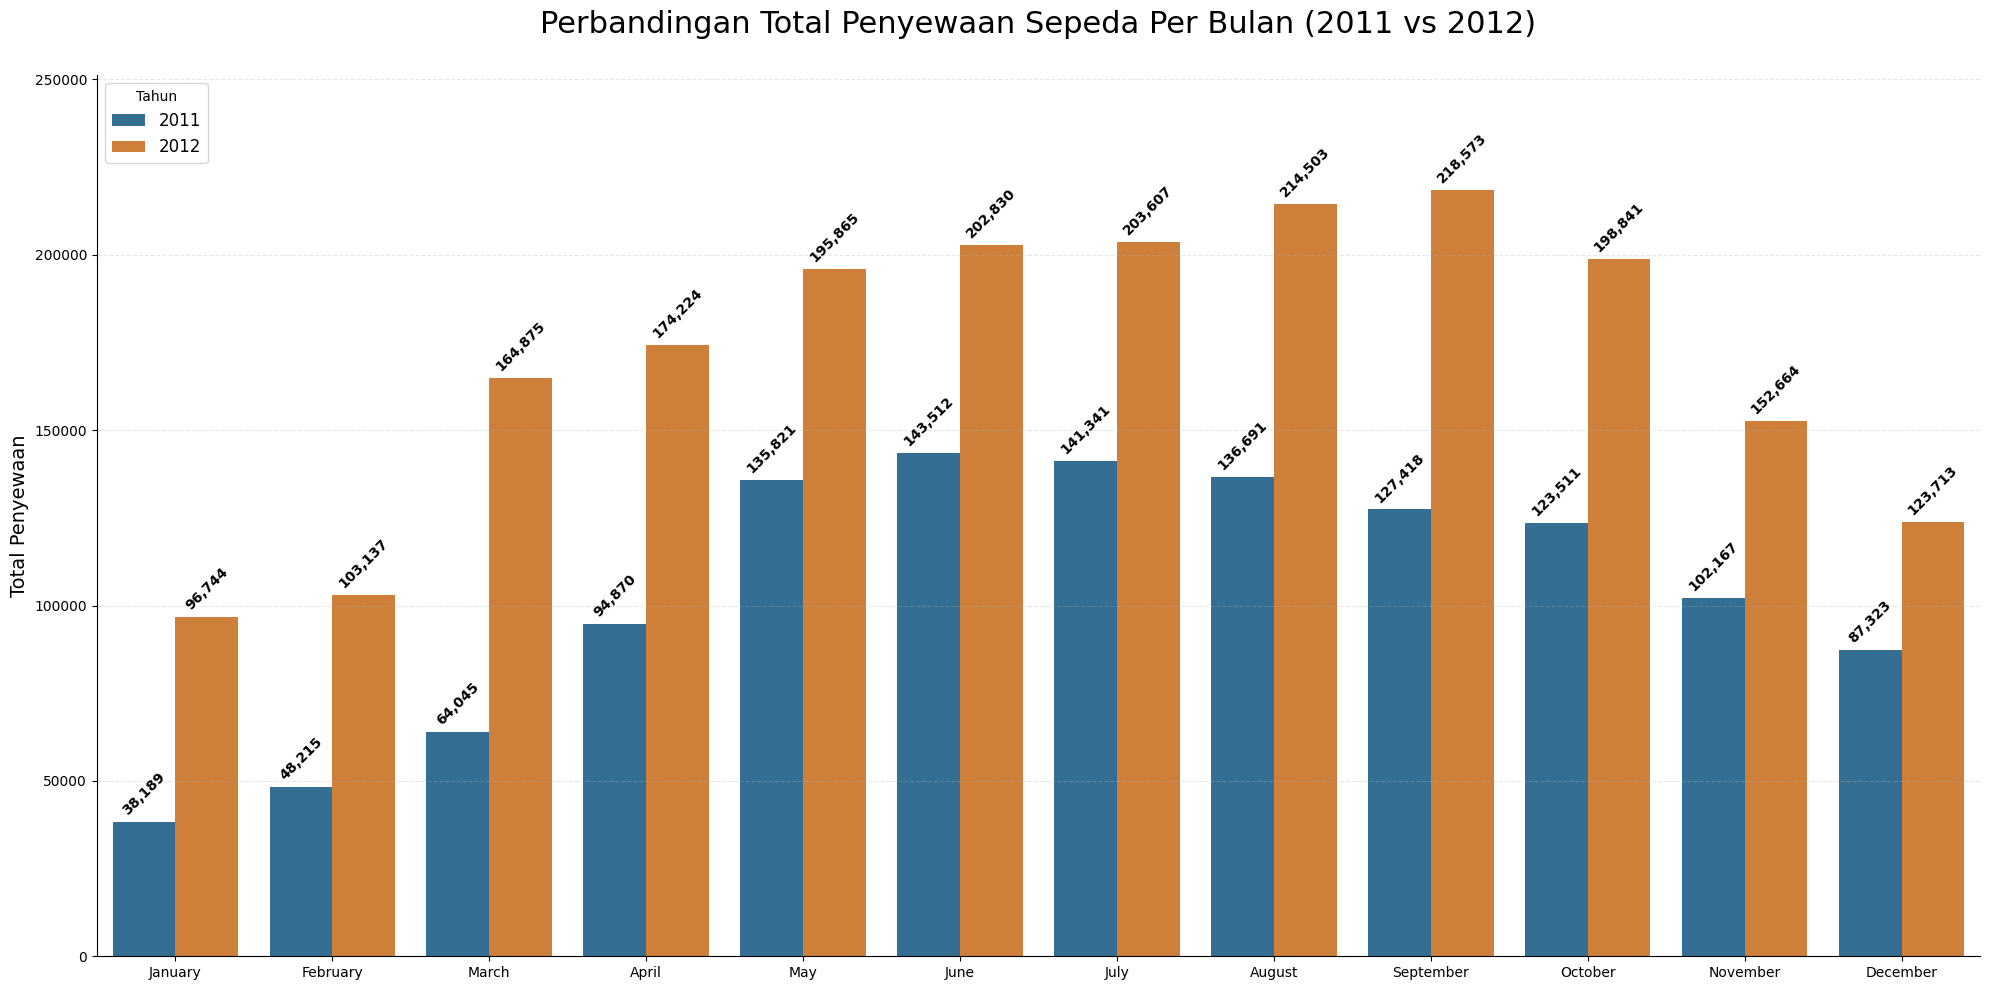

In [16]:
# Persiapan Data
monthly_trend_df = df_day_clean.groupby(by=["yr", "mnth"], observed=True).agg({
    "cnt": "sum"
}).reset_index()

# Perbaikan Mapping Tahun
monthly_trend_df['yr'] = monthly_trend_df['yr'].astype(str)
monthly_trend_df['yr'] = monthly_trend_df['yr'].replace({'0': '2011', '1': '2012', '0.0': '2011', '1.0': '2012'})

# Urutan Bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_trend_df['mnth'] = pd.Categorical(monthly_trend_df['mnth'], categories=month_order, ordered=True)
monthly_trend_df = monthly_trend_df.sort_values(['yr', 'mnth'])

# Visualisasi
plt.figure(figsize=(20, 10)) 

colors = {'2011': '#2471A3', '2012': '#E67E22'}

# Simpan barplot ke dalam variabel 'ax' untuk menambahkan label
ax = sns.barplot(
    data=monthly_trend_df, 
    x='mnth', 
    y='cnt', 
    hue='yr', 
    palette=colors
)

for container in ax.containers:
    ax.bar_label(container, 
                 fmt='{:,.0f}', 
                 padding=3,     
                 fontsize=10, 
                 fontweight='bold',
                 rotation=45)   
# 5. Detail Estetika
plt.title('Perbandingan Total Penyewaan Sepeda Per Bulan (2011 vs 2012)', loc='center', fontsize=22, pad=30)
plt.ylabel('Total Penyewaan', fontsize=14)
plt.xlabel(None)

# Menambah limit sumbu Y sedikit agar angka paling atas tidak terpotong
plt.ylim(0, monthly_trend_df['cnt'].max() * 1.15)

plt.legend(title='Tahun', loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()


**Insight:** 
- Sepanjang tahun 2012 (batang oranye), jumlah penyewaan menunjukkan tren pertumbuhan yang sangat positif sejak awal tahun. Dimulai dari 96.744 pada bulan Januari, volume penyewaan terus meningkat hingga melampaui angka 200.000 di bulan Juni dan mencapai puncaknya di bulan September. Setelah itu, volume mulai melandai pada kuartal terakhir tahun 2012.
- Pada Tahun 2012 menunjukkan performa yang secara konsisten jauh lebih tinggi dibandingkan tahun 2011 (batang biru). Tidak ada satu bulan pun di tahun 2012 yang jumlah penyewaannya lebih rendah daripada bulan yang sama di tahun sebelumnya.
- Lonjakan jumlah pengguna yang paling mencolok dibandingkan tahun sebelumnya terlihat pada bulan September 2012. Pada bulan ini, jumlah penyewaan mencapai angka tertinggi sepanjang periode, yaitu 218.573, yang berarti terdapat selisih sebesar 91.155 penyewaan dibandingkan dengan bulan September 2011 (127.418).
- Selain September, bulan Maret juga menunjukkan lonjakan pertumbuhan yang luar biasa. Jumlah penyewaan meningkat drastis dari 64.045 di tahun 2011 menjadi 164.875 di tahun 2012, yang mengindikasikan pertumbuhan volume lebih dari dua kali lipat.

### Pertanyaan 2: Bagaimana perbedaan pola aktivitas antara pengguna Casual dan Registered pada jam-jam sibuk (rush hours) di hari kerja (working day)?

C:\Users\andika arsana\AppData\Local\Temp\ipykernel_32668\3317810079.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  working_day_df = df_hour_clean[df_hour_clean["workingday"] == "Working Day"].groupby(by="hr").agg({


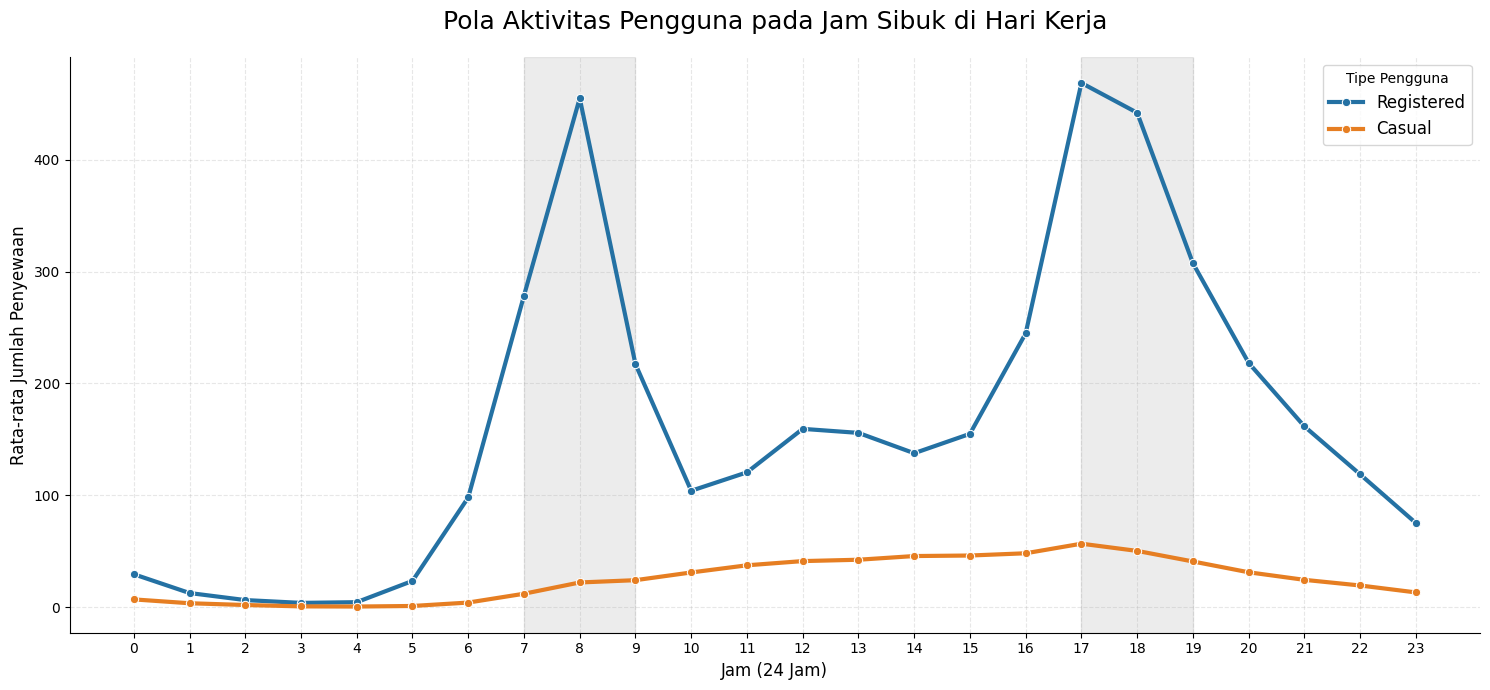

In [17]:
# Menyiapkan data: Filter hari kerja dan hitung rata-rata per jam
working_day_df = df_hour_clean[df_hour_clean["workingday"] == "Working Day"].groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean"
}).reset_index()

# 2Membuat Visualisasi Line Chart
plt.figure(figsize=(15, 7))

# Plot Garis untuk Pengguna Registered
sns.lineplot(
    data=working_day_df, x='hr', y='registered', 
    label='Registered', marker='o', linewidth=3, color='#2471A3' # Biru
)

# Plot Garis untuk Pengguna Casual
sns.lineplot(
    data=working_day_df, x='hr', y='casual', 
    label='Casual', marker='o', linewidth=3, color='#E67E22' # Oranye
)

# Detail Estetika
plt.title('Pola Aktivitas Pengguna pada Jam Sibuk di Hari Kerja', fontsize=18, pad=20)
plt.xlabel('Jam (24 Jam)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Tipe Pengguna', fontsize=12)

# Memberi highlight pada area jam sibuk (07-09 dan 17-19)
plt.axvspan(7, 9, color='gray', alpha=0.15, label='Rush Hour Pagi')
plt.axvspan(17, 19, color='gray', alpha=0.15, label='Rush Hour Sore')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:** 
- Garis biru (Registered) menunjukkan pola "Double Peak" yang sangat tajam. Lonjakan penyewaan terjadi tepat di dalam kotak abu-abu (pukul 08:00 dan 17:00). Ini membuktikan bahwa pengguna terdaftar adalah pekerja atau pelajar yang menggunakan sepeda sebagai alat transportasi rutin untuk berkomuter.
- Garis oranye (Casual) memiliki tren yang jauh lebih landai. Tidak ada lonjakan drastis di jam 8 pagi. Aktivitas mereka justru meningkat perlahan saat hari mulai siang dan mencapai puncaknya di sore hari (sekitar jam 17:00). Ini mengindikasikan penggunaan untuk tujuan rekreasi atau kebutuhan non-rutin.
- Terdapat perbedaan volume yang sangat besar antara kedua tipe pengguna. Pengguna Registered mendominasi total penyewaan di setiap jamnya, terutama saat jam sibuk di   mana perbandingannya bisa mencapai lebih dari 8 kali lipat dibandingkan pengguna Casual.
- Di antara dua jam sibuk (sekitar pukul 10:00 - 15:00), jumlah pengguna Registered menurun drastis namun tetap stabil di angka tertentu. Hal ini menunjukkan bahwa ada kelompok pengguna rutin yang tetap menggunakan sepeda di luar jam berangkat/pulang kantor.
- Kotak abu-abu tersebut adalah "Highlight Area" yang menandakan Jam Sibuk (Rush Hours) di hari kerja seperti Pagi hari (Jam 07:00 - 09:00) yang menandakan waktu keberangkatan kerja atau sekolah dn sore hari (Jam 17:00 - 19:00) yang menandakan waktu pulang kerja atau sekolah. Area ini sengaja diwarnai berbeda untuk mempermudah pembaca melihat bahwa lonjakan data terjadi tepat di dalam jendela waktu tersebut.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana pengaruh pengelompokan suhu udara (Temperature Binning: Cold, Moderate, Hot) terhadap total penyewaan sepeda, dan pada kategori suhu manakah pengguna cenderung paling aktif bersepeda?

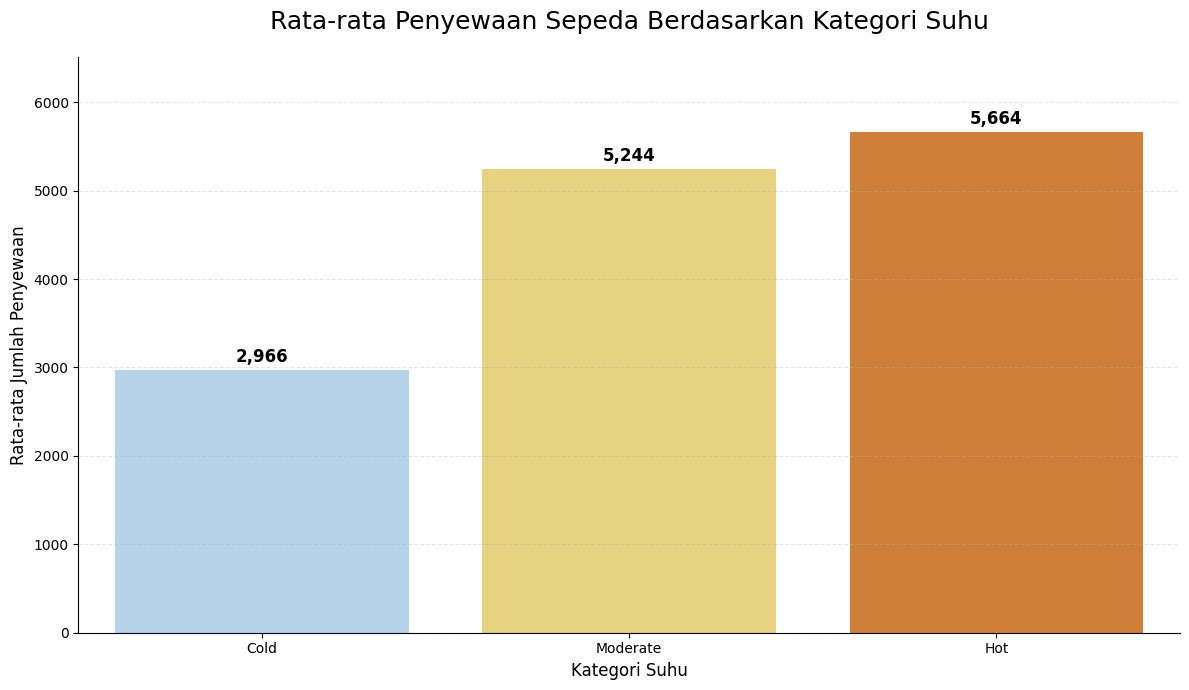

In [18]:
# Menyiapkan data (menggunakan rata-rata agar perbandingannya adil)
temp_analysis_df = df_day_clean.groupby(by="temp_bins", observed=True).agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).reset_index()

# Membuat Visualisasi Bar Chart
plt.figure(figsize=(12, 7))

# Kita gunakan barplot untuk total penyewaan (cnt)
ax = sns.barplot(
    data=temp_analysis_df, 
    x='temp_bins', 
    y='cnt', 
    palette=['#AED6F1', '#F7DC6F', '#E67E22'], # Biru Muda (Cold), Kuning (Moderate), Oranye (Hot)
    hue='temp_bins',
    legend=False
)

# Menambahkan Data Labels di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=12, fontweight='bold')

# 4. Detail Estetika
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Suhu', fontsize=18, pad=20)
plt.xlabel('Kategori Suhu', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.ylim(0, temp_analysis_df['cnt'].max() * 1.15) # Memberi ruang untuk label

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

**Insight:**
- Pengguna cenderung paling aktif bersepeda pada kategori suhu Hot, dengan rata-rata penyewaan mencapai angka tertinggi sebesar 5.664. Hal ini menunjukkan bahwa cuaca yang cenderung panas/hangat bukanlah penghalang, melainkan pendorong utama orang untuk beraktivitas di luar ruangan menggunakan sepeda.
- Terdapat tren kenaikan yang konsisten seiring dengan meningkatnya suhu udara. Dari suhu Cold (2.966) ke Moderate (5.244), terjadi lonjakan penggunaan yang cukup tinggi. Ini membuktikan bahwa suhu udara adalah variabel krusial yang menentukan volume bisnis.
- Kategori Cold memiliki angka penyewaan paling rendah (2.966). Ini menunjukkan bahwa pengguna memiliki resistansi yang tinggi untuk bersepeda saat suhu udara menurun drastis, kemungkinan karena faktor kenyamanan fisik atau risiko cuaca yang menyertainya.
- Perbedaan antara kategori Moderate (5,244) dan Hot (5,664) tidak terlalu ekstrem dibandingkan selisih dari kategori Cold. Ini mengindikasikan bahwa selama suhu berada di level yang "tidak dingin", minat pengguna tetap terjaga di level yang tinggi.
- Berdasarkan data ini, perusahaan dapat mengoptimalkan jadwal pemeliharaan sepeda (maintenance) pada periode suhu Cold karena beban penggunaan sedang rendah, dan memastikan ketersediaan sepeda maksimal pada hari-hari dengan prakiraan cuaca Moderate hingga Hot.

## Conclusion

1. Tren Pertumbuhan Penyewaan Sepeda Tahunan dan Bulanan
Analisis terhadap perkembangan tren bulanan menunjukkan bahwa tahun 2012 mengalami pertumbuhan volume penyewaan yang sangat signifikan dibandingkan dengan tahun 2011. Pola pertumbuhan ini terlihat konsisten di setiap bulan, di mana bisnis berhasil mempertahankan performa yang jauh lebih tinggi dibandingkan tahun sebelumnya. Lonjakan jumlah pengguna yang paling mencolok terjadi pada bulan September 2012, di mana total penyewaan mencapai angka puncak sebesar 218.573 unit. Hal ini membuktikan bahwa terdapat peningkatan minat masyarakat yang sangat kuat dan ekspansi pasar yang sehat pada tahun kedua operasional layanan.

2. Pola Aktivitas Pengguna pada Jam Sibuk di Hari Kerja
Perbedaan pola aktivitas antara pengguna Casual dan Registered pada hari kerja menunjukkan karakteristik yang sangat kontras. Pengguna Registered memiliki pola aktivitas "dua puncak" (double peak) yang tajam pada jam berangkat kerja sekitar pukul 08.00 dan jam pulang kerja antara pukul 17.00 hingga 18.00, yang mengindikasikan bahwa kelompok ini menggunakan sepeda sebagai moda transportasi utama untuk berkomuter. Di sisi lain, pengguna Casual menunjukkan pola aktivitas yang lebih landai dan cenderung bersifat rekreasi, di mana penggunaan meningkat secara bertahap menuju siang hari tanpa adanya lonjakan drastis pada jam sibuk pagi hari.

3. Pengaruh Kategori Suhu Udara terhadap Intensitas Bersepeda
Pengelompokan suhu udara memberikan gambaran bahwa suhu merupakan faktor lingkungan krusial yang menentukan volume penyewaan, di mana pengguna cenderung paling aktif bersepeda pada kategori suhu Hot dengan rata-rata penyewaan tertinggi sebesar 5.664. Terdapat korelasi positif yang jelas antara kenaikan suhu dan jumlah penyewaan, yang ditandai dengan lonjakan volume yang signifikan saat kondisi udara beralih dari kategori Cold ke Moderate. Sebaliknya, kategori suhu Cold mencatatkan angka terendah, yang menunjukkan bahwa suhu udara yang dingin menjadi penghambat utama bagi kenyamanan dan minat pengguna dalam melakukan aktivitas bersepeda.